# Proyecto Tienda Aurelion

## 1. Origen de los datos

El conjunto de datos proviene de la base de datos denominada Proyecto_Tienda_Aurelion, la cual contiene información sobre las ventas realizadas entre enero y junio de 2024. Esta base de datos está compuesta por diversas tablas, entre las que se incluyen: clientes, productos, ventas, ciudades, métodos de pago, categorías y detalle de ventas.

## 2. Negocio

La tienda Aurelion es un negocio presente en distintas ciudades de Argentina, dedicado a la comercialización de productos pertenecientes a las categorías de Limpieza y Alimentos.

## 3. Objetivos del proyecto

1. ¿Cuáles son los 10 productos más vendidos en cantidad?
2. ¿Cuáles son los 10 productos que generan más ingresos?
3. ¿Quiénes son los 20 clientes que más compran en términos de ingresos?
4. ¿Cuál es la compra media por cliente mensualmente?
5. ¿Cuántos pedidos totales se han realizado?
6. ¿Cuál es el valor promedio por pedido mensualmente?
7.  ¿Cuál es el método de pago que más se utiliza?
8.  ¿En qué ciudades generan más ingresos?
9.  ¿En qué ciudades se realizaron más compras en cantidad?
10. ¿Cuál es el ingreso total generado?
11. ¿Cómo ha sido la tendencia de ingresos?
12. ¿Cuál es la cantidad total vendida?
13. ¿Cómo ha sido la tendencia de la cantidad vendida?
14. ¿Cuáles son las categorías más vendidas en cantidad?
15. ¿Qué categorías generan más ingresos?

Instalamos el paquete **sqlalchemy**. La cual nos permite conectar Python con SQLserver.

In [1]:
# !pip install sqlalchemy

Importamos los paquetes necesarios

In [ ]:
import sqlalchemy
from sqlalchemy import create_engine
import urllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
params = urllib.parse.quote_plus(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=Proyecto_Tienda_Aurelion;"
    "Trusted_Connection=yes;"
    "Encrypt=optional;"
)

engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

con = engine.connect()
print("Conexión exitosa")


C:\Users\HP\AppData\Local\Temp\ipykernel_8892\2203891210.py:11: SAWarning: Unrecognized server version info '17.0.800.3'.  Some SQL Server features may not function properly.
  con = engine.connect()


Conexión exitosa


##  Análisis Exploratorio de datos 



In [4]:
query1 = '''
        SELECT *, YEAR(fecha) AS año, MONTH(fecha) AS mes FROM dbo.ventas'''
df_fecha_ventas = pd.read_sql(query1, con)
df_fecha_ventas.head()

,id_venta,fecha,id_cliente,id_medio_pago,año,mes
0,1,2024-06-19,62,1,2024,6
1,2,2024-03-17,49,2,2024,3
2,3,2024-01-13,20,1,2024,1
3,4,2024-02-27,36,3,2024,2
4,5,2024-06-11,56,1,2024,6


* Las ventas se realizaron desde enero hasta junio de 2024

In [5]:
month = np.sort(df_fecha_ventas['mes'].unique())
year = df_fecha_ventas['año'].unique()
print(f"meses = {month}")
print(f"año = {year}")

meses = [1 2 3 4 5 6]
año = [2024]


* Se observa que las ciudades son del país de Argentina.

In [6]:
query2 = "SELECT * FROM dbo.ciudades"
df_ciudades = pd.read_sql(query2, con)
df_ciudades.head()

,id_ciudad,ciudad
0,1,Carlos Paz
1,2,Rio Cuarto
2,3,Cordoba
3,4,Villa Maria
4,5,Alta Gracia


#### Distribución de precios mediante diagrama de caja e histograma, respectivamente.

In [7]:
query_productos = '''SELECT * FROM dbo.productos'''
df_productos = pd.read_sql(query_productos, con)
df_productos.head()

,id_producto,nombre_producto,precio_unitario,id_categoria
0,1,Coca Cola 1.5L,2347.0,1
1,2,Pepsi 1.5L,4973.0,2
2,3,Sprite 1.5L,4964.0,1
3,4,Fanta Naranja 1.5L,2033.0,2
4,5,Agua Mineral 500ml,4777.0,1


In [8]:
df_productos['precio_unitario'].describe()

count     100.000000
mean     2718.550000
std      1381.635324
min       272.000000
25%      1590.000000
50%      2516.000000
75%      4026.500000
max      4982.000000
Name: precio_unitario, dtype: float64

Se observa que la media  es mayor que la mediana. Por lo tanto, la distribución es asimétrica con cola a la derecha (sesgada a la derecha).

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


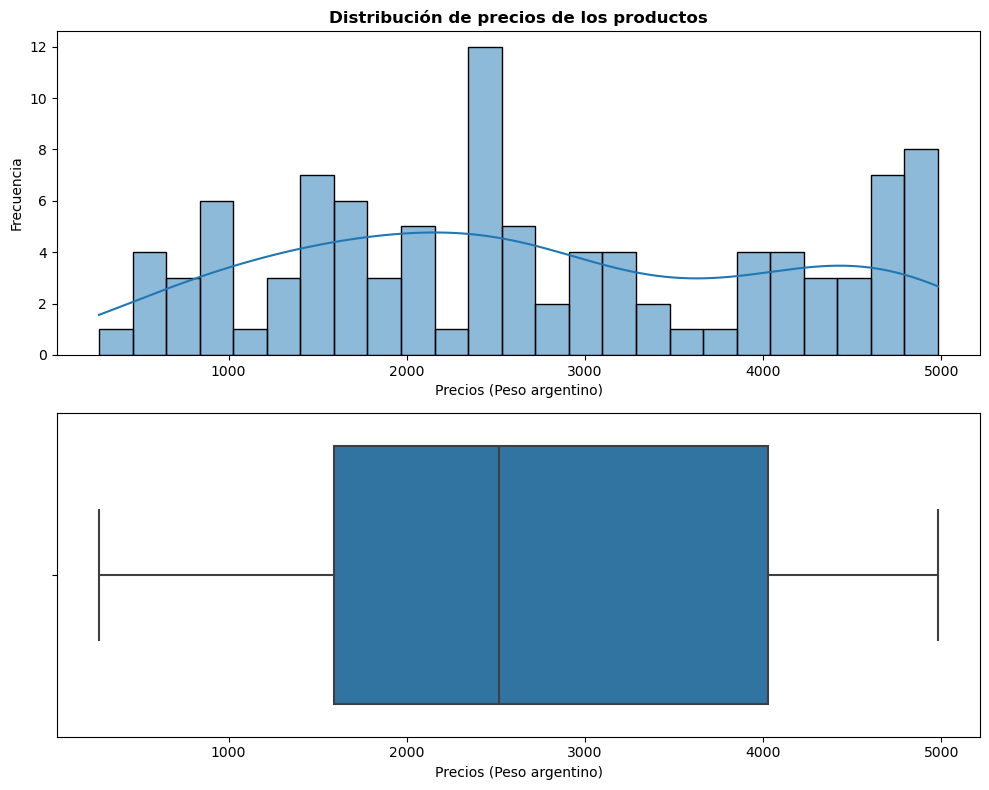

In [9]:
# Visualizaciones
plt.figure(figsize=(10, 8))

# Gráfico de distribución de precios de alquiler
plt.subplot(2, 1, 1)
sns.histplot(data= df_productos, x = 'precio_unitario', stat='count', bins= 25, kde = True)
plt.title('Distribución de precios de los productos',weight='bold')
plt.xlabel('Precios (Peso argentino)')
plt.ylabel('Frecuencia')

#plt.xlim(0, 5000)
# Gráfico de caja
plt.subplot(2, 1, 2)
sns.boxplot(data= df_productos, x= 'precio_unitario')
plt.xlabel('Precios (Peso argentino)')
plt.tight_layout()
plt.show()

#### Análisis del histograma:

- El eje $x$ representa el precio en pesos argentinos, mientras que el eje $y$ muestra la frecuencia de productos en los distintos niveles de precio. Se observa una ligera asimetría positiva (sesgo hacia la derecha), lo que indica que existen algunos productos con precios relativamente altos.

#### Análisis del gráfico de caja y bigote:
- Se observa que el 50% de los productos su precio está entre 1590 y 4026.5 pesos argentinos. No se observan valores atípicos.

#### Distribución de las ventas totales (Importe) mediante diagrama de caja e histograma, respectivamente.

In [10]:
query_detalle_ventas = '''SELECT *, (cantidad * precio_unitario) AS importe FROM dbo.detalle_ventas'''
df_detalle_ventas = pd.read_sql(query_detalle_ventas, con)
df_detalle_ventas.head()

,id_venta,id_producto,cantidad,precio_unitario,importe
0,1,90,1,2902.0,2902.0
1,2,22,1,2069.0,2069.0
2,2,39,5,469.0,2345.0
3,2,70,2,4061.0,8122.0
4,2,79,4,2420.0,9680.0


In [11]:
df_detalle_ventas['importe'].describe()

count      343.000000
mean      7730.078717
std       5265.543077
min        272.000000
25%       3489.000000
50%       6702.000000
75%      10231.500000
max      24865.000000
Name: importe, dtype: float64

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


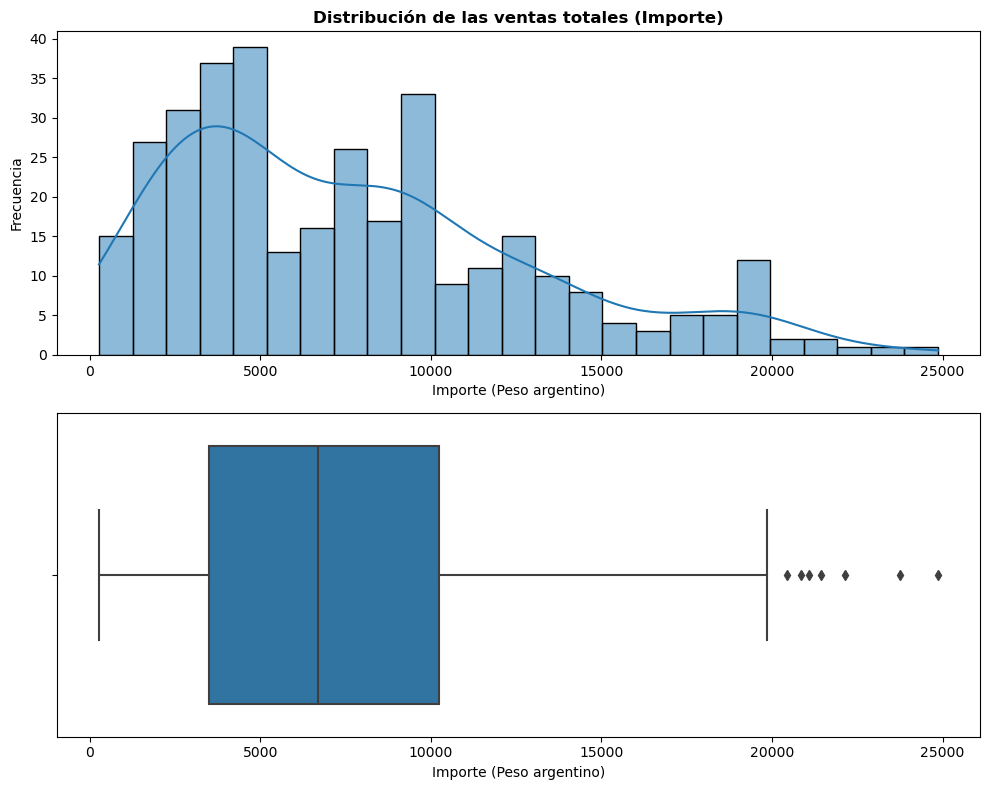

In [12]:
# Visualizaciones
plt.figure(figsize=(10, 8))

# Gráfico de distribución de precios de alquiler
plt.subplot(2, 1, 1)
sns.histplot(data= df_detalle_ventas, x = 'importe', stat='count', bins= 25, kde = True)
plt.title('Distribución de las ventas totales (Importe)',weight='bold')
plt.xlabel('Importe (Peso argentino)')
plt.ylabel('Frecuencia')

#plt.xlim(0, 5000)
# Gráfico de caja
plt.subplot(2, 1, 2)
sns.boxplot(data= df_detalle_ventas, x= 'importe')
plt.xlabel('Importe (Peso argentino)')
plt.tight_layout()
plt.show()

Encontrar el límite superior e límite inferior del boxplot.

In [13]:
rango_intercuartilico = df_detalle_ventas['importe'].quantile(0.75) - df_detalle_ventas['importe'].quantile(0.25)
# limite_inferior_importe = df_detalle_ventas['importe'].quantile(0.25) - (1.5 * (rango_intercuartilico))
limite_superior_importe = df_detalle_ventas['importe'].quantile(0.75) +  (1.5 * (rango_intercuartilico))
# print(round(limite_inferior_importe, 0))
print(round(limite_superior_importe, 0))

20345.0


Encontramos los valores atípicos


In [14]:
query_producto_detalle_ventas = '''
                                SELECT *, (dv.cantidad * dv.precio_unitario) AS importe FROM dbo.detalle_ventas AS dv
                                INNER JOIN dbo.productos AS prod ON prod.id_producto = dv.id_producto
                                WHERE (dv.cantidad * dv.precio_unitario) >= 20345.0;
                                '''
df_unir_producto_detalle_ventas = pd.read_sql(query_producto_detalle_ventas, con)
df_unir_producto_detalle_ventas

,id_venta,id_producto,cantidad,precio_unitario,id_producto,nombre_producto,precio_unitario,id_categoria,importe
0,16,35,5,4430.0,35,Barrita de Cereal 30g,4430.0,1,22150.0
1,21,76,5,4286.0,76,Pizza Congelada Muzzarella,4286.0,2,21430.0
2,50,58,5,4752.0,58,Caramelos Masticables,4752.0,2,23760.0
3,63,8,5,4218.0,8,Energética Nitro 500ml,4218.0,2,21090.0
4,75,2,5,4973.0,2,Pepsi 1.5L,4973.0,2,24865.0
5,94,86,5,4090.0,86,Jugo en Polvo Limón,4090.0,2,20450.0
6,110,6,5,4170.0,6,Jugo de Naranja 1L,4170.0,2,20850.0


### ¿Cuál es el ingreso total generado?

In [15]:
query_importe_total = '''
                        SELECT SUM(detalle_ventas_importe.importe) AS "Importe Total"
                        FROM (SELECT *, (dv.cantidad * dv.precio_unitario) AS importe FROM dbo.detalle_ventas AS dv) AS detalle_ventas_importe;
                      '''
importe_total = pd.read_sql(query_importe_total, con)
importe_total

,Importe Total
0,2651417.0


### ¿Cuál es la cantidad total vendida?

In [16]:
query_cantidad_total = '''SELECT SUM(dv.cantidad) AS "Cantidad  Total Vendida" 
                          FROM dbo.detalle_ventas AS dv'''
cantidad_vendida = pd.read_sql(query_cantidad_total, con)
cantidad_vendida

,Cantidad Total Vendida
0,1016


### ¿Cómo ha sido la tendencia de los ingresos mensualmente?

In [17]:
query_tendencia_ingresos = ''' 
                               SELECT MONTH(vt.fecha) AS mes, FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes, SUM(dv.cantidad * dv.precio_unitario) AS importe 
                               FROM dbo.detalle_ventas AS dv 
                               INNER JOIN dbo.ventas vt ON vt.id_venta = dv.id_venta
                               GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                               ORDER BY MONTH(vt.fecha) ASC ;
                            '''
df_tendencia_ingresos = pd.read_sql(query_tendencia_ingresos, con)
df_tendencia_ingresos

,mes,nombre_mes,importe
0,1,enero,529840.0
1,2,febrero,407041.0
2,3,marzo,388263.0
3,4,abril,251524.0
4,5,mayo,561832.0
5,6,junio,512917.0


In [18]:
crecimiento_mes_a_mes = np.zeros(6)
for i in range(6):
    if i == 0:
        crecimiento_mes_a_mes[i] = np.nan
    else:    
        crecimiento_mes_a_mes[i] = round(((df_tendencia_ingresos['importe'][i] - df_tendencia_ingresos['importe'][i - 1]) / df_tendencia_ingresos['importe'][i - 1]) * 100,1)

print(crecimiento_mes_a_mes)

[  nan -23.2  -4.6 -35.2 123.4  -8.7]


Calculamos el crecimiento mes a mes del importe

In [19]:
df_tendencia_ingresos['crecimiento_mes_a_mes (%)'] = crecimiento_mes_a_mes
df_tendencia_ingresos

,mes,nombre_mes,importe,crecimiento_mes_a_mes (%)
0,1,enero,529840.0,NaN
1,2,febrero,407041.0,-23.2
2,3,marzo,388263.0,-4.6
3,4,abril,251524.0,-35.2
4,5,mayo,561832.0,123.4
5,6,junio,512917.0,-8.7


Tasa de Crecimiento Mensual Compuesta (CMGR) del importe

In [20]:
CMGR = round((((df_tendencia_ingresos['importe'][5] / df_tendencia_ingresos['importe'][0]) ** (1 / (df_tendencia_ingresos.shape[0]-1))) - 1) * 100,1)
print(f'Tasa de Crecimiento Mensual Compuesta = {CMGR}%')

Tasa de Crecimiento Mensual Compuesta = -0.6%


En promedio, los ingresos de la tienda decrecieron un -0.6% mensual entre enero y junio. 

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


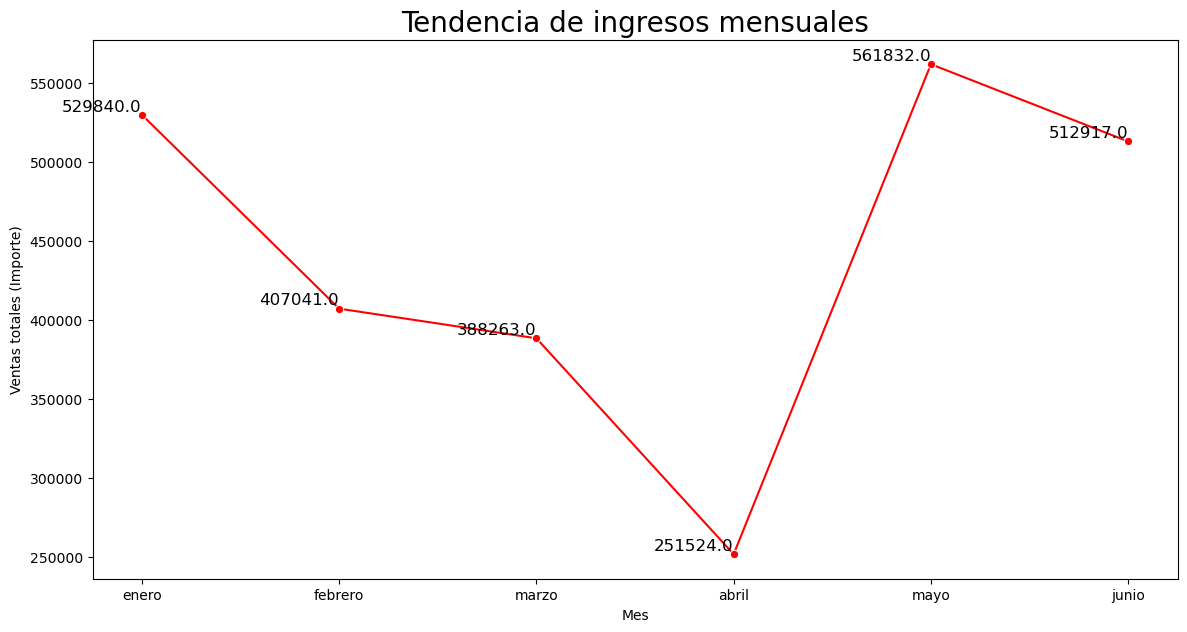

In [21]:
plt.figure(figsize=(14, 7))

# Crear el gráfico de líneas
sns.lineplot(df_tendencia_ingresos, x= 'nombre_mes', y = 'importe', color = 'red', linestyle='-', marker='o')

# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Ventas totales (Importe)')
plt.title('Tendencia de ingresos mensuales', fontsize = 20)

# Agregar etiquetas sobre cada punto
for i in range(len(df_tendencia_ingresos)):
    plt.text(df_tendencia_ingresos['nombre_mes'][i],
             df_tendencia_ingresos['importe'][i] + 10000,   # Ajusta la altura de la etiqueta
             str(round(df_tendencia_ingresos['importe'][i], 0)),
             ha='right', va='top', fontsize=12, color='black')

plt.show()

## ¿Cómo ha sido la tendencia de la cantidad vendida mensualmente?

In [22]:
query_tendencia_cantidad = ''' 
                               SELECT MONTH(vt.fecha) AS mes, FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes, SUM(dv.cantidad) AS cantidad 
                               FROM dbo.detalle_ventas AS dv 
                               INNER JOIN dbo.ventas vt ON vt.id_venta = dv.id_venta
                               GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                               ORDER BY MONTH(vt.fecha) ASC ;
                            '''
df_tendencia_cantidad = pd.read_sql(query_tendencia_cantidad, con)
df_tendencia_cantidad

,mes,nombre_mes,cantidad
0,1,enero,205
1,2,febrero,173
2,3,marzo,149
3,4,abril,100
4,5,mayo,206
5,6,junio,183


Calculamos el crecimiento mes a mes de la cantidad vendida

In [23]:
crecimiento_mes_a_mes = np.zeros(6)
for i in range(6):
    if i == 0:
        crecimiento_mes_a_mes[i] = np.nan
    else:    
        crecimiento_mes_a_mes[i] = round(((df_tendencia_cantidad['cantidad'][i] - df_tendencia_cantidad['cantidad'][i - 1]) / df_tendencia_cantidad['cantidad'][i - 1]) * 100,1)

print(crecimiento_mes_a_mes)

[  nan -15.6 -13.9 -32.9 106.  -11.2]


In [24]:
df_tendencia_cantidad['crecimiento_mes_a_mes (%)'] = crecimiento_mes_a_mes
df_tendencia_cantidad

,mes,nombre_mes,cantidad,crecimiento_mes_a_mes (%)
0,1,enero,205,NaN
1,2,febrero,173,-15.6
2,3,marzo,149,-13.9
3,4,abril,100,-32.9
4,5,mayo,206,106.0
5,6,junio,183,-11.2


Tasa de Crecimiento Mensual Compuesta (CMGR) de la cantidad vendida

In [25]:
CMGR = round((((df_tendencia_cantidad['cantidad'][5] / df_tendencia_cantidad['cantidad'][0]) ** (1 / (df_tendencia_cantidad.shape[0]-1))) - 1) * 100, 1)
print(f'Tasa de Crecimiento Mensual Compuesta = {CMGR}%')

Tasa de Crecimiento Mensual Compuesta = -2.2%


En promedio, las cantidades vendidas de la tienda decrecieron un -2.2% mensual entre enero y junio. 

d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


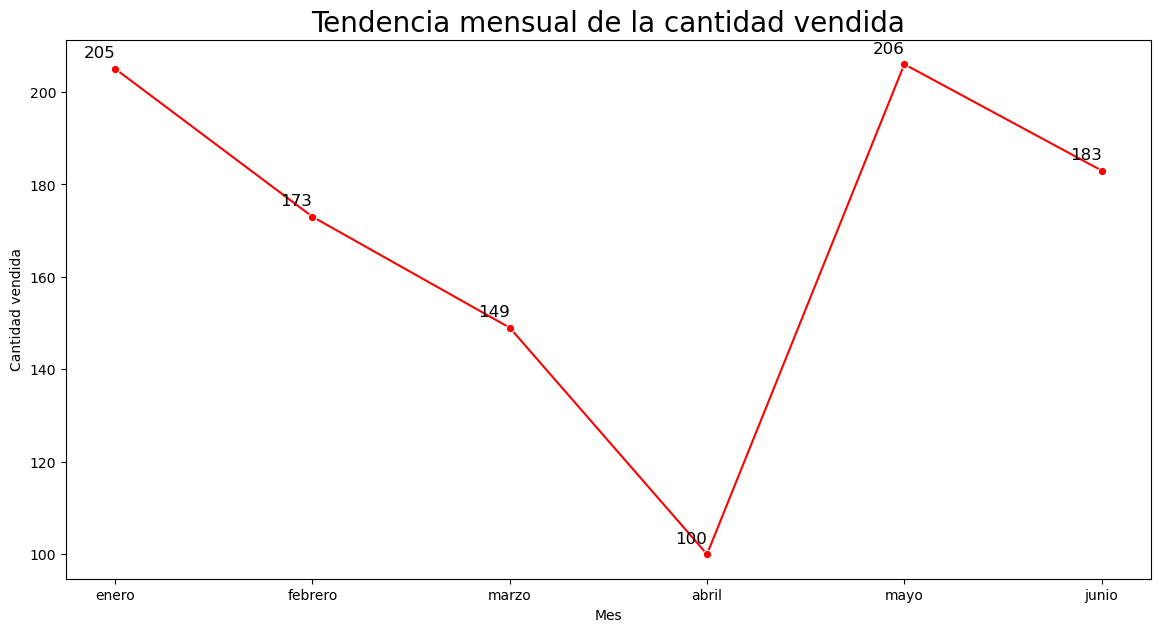

In [26]:
plt.figure(figsize=(14, 7))

# Crear el gráfico de líneas
sns.lineplot(df_tendencia_cantidad, x= 'nombre_mes', y = 'cantidad', color = 'red', linestyle='-', marker='o')

# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Cantidad vendida')
plt.title("Tendencia mensual de la cantidad vendida", fontsize = 20)

# Agregar etiquetas sobre cada punto
for i in range(len(df_tendencia_cantidad)):
    plt.text(df_tendencia_cantidad['nombre_mes'][i],
             df_tendencia_cantidad['cantidad'][i] + 5,   # Ajusta la altura de la etiqueta
             str(round(df_tendencia_cantidad['cantidad'][i], 0)),
             ha='right', va='top', fontsize=12, color='black')

plt.show()

#### Análisis de la tendencia mensual de la cantidad vendida y los ingresos (importe)

* Primer trimestre (enero–marzo): Se observa una tendencia de descenso constante tanto en la cantidad vendida como en los ingresos generados.

* Abril fue el mes con peor desempeño, registrando los niveles más bajos de ventas e ingresos.

* Mayo alcanzó el pico máximo de ingresos, aunque se ubicó en el segundo lugar en cantidad vendida.

* Enero se posicionó como el segundo mes con mayores ingresos y el primero en cantidad vendida, mostrando un buen inicio de año.

* En junio se registró un leve descenso respecto al pico de mayo; aun así, se ubicó como el tercer mes con mayores ingresos y cantidad vendida.

## ¿Cuál es el método de pago que más se utiliza?

In [27]:
query_ventas_medio_pago = '''
                            SELECT mp.medio_pago,  COUNT(vt.id_venta) AS cantidad_de_ventas
                            FROM dbo.ventas vt
                            INNER JOIN dbo.medio_de_pago mp ON mp.id_medio_pago = vt.id_medio_pago
                            GROUP BY mp.medio_pago
                            ORDER BY COUNT(vt.id_venta) DESC;
                          '''
df_ventas_medio_pago = pd.read_sql(query_ventas_medio_pago, con)
df_ventas_medio_pago

,medio_pago,cantidad_de_ventas
0,efectivo,37
1,qr,30
2,transferencia,27
3,tarjeta,26


In [28]:
len(df_ventas_medio_pago)

4

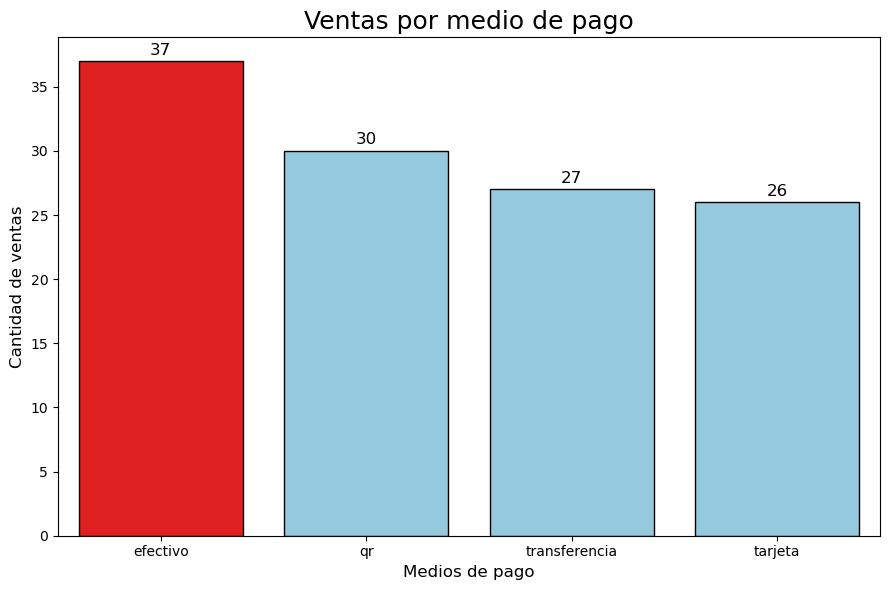

In [29]:
plt.figure(figsize=(9, 6))

# Paleta: primer valor rojo, resto azul suave
colors = ['red'] + ['#87CEEB'] * (len(df_ventas_medio_pago) - 1)

sns.barplot(
    data=df_ventas_medio_pago,
    x='medio_pago',
    y='cantidad_de_ventas',
    palette=colors,
    edgecolor='black'
)

# Títulos y etiquetas
plt.title("Ventas por medio de pago", fontsize=18)
plt.xlabel("Medios de pago", fontsize=12)
plt.ylabel("Cantidad de ventas", fontsize=12)

# Añadir valores encima de cada barra
for i, value in enumerate(df_ventas_medio_pago['cantidad_de_ventas']):
    plt.text(i, value + 0.5, str(value),
             ha='center', fontsize=12, color='black')

# Ajustar layout
plt.tight_layout()
plt.show()

Análisis:

* 37 ventas se realizaron en efectivo. Esto muestra que muchos clientes aún prefieren pagar de forma tradicional, posiblemente por costumbre o comodidad.

* Los pagos digitales (QR, transferencia y tarjeta) en conjunto alcanzan 83 ventas, superando al efectivo. Esto indica que cada vez más personas optan por métodos digitales, reflejando una tendencia creciente hacia la digitalización.

* El método digital más utilizado es el pago mediante QR, ya que representa una alternativa rápida, cómoda y segura para los clientes.

Referencias:
* https://pepperfinance.es/blog/finanzas/8-metodos-pago-online-utilizados/

* https://prometeoapi.com/blog/pagos-digitales

* https://www.santander.com/es/stories/pagos-digitales-que-son-y-cuales-son-los-mas-usados

## ¿En qué ciudades generan más ingresos?

In [30]:
query_ciudad_importe = '''
                        SELECT cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR) AS ciudad, SUM(dv.cantidad * dv.precio_unitario) AS importe 
                        FROM dbo.clientes cl
                        INNER JOIN dbo.ciudades cdd ON cdd.id_ciudad = cl.id_ciudad
                        INNER JOIN dbo.ventas vt ON vt.id_cliente = cl.id_cliente
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR)
                        ORDER BY SUM(dv.cantidad * dv.precio_unitario) DESC;
                       '''
df_ciudad_importe = pd.read_sql(query_ciudad_importe, con)
df_ciudad_importe

,id_ciudad,ciudad,importe
0,2,Rio Cuarto,792203.0
1,5,Alta Gracia,481504.0
2,3,Cordoba,481482.0
3,1,Carlos Paz,353852.0
4,4,Villa Maria,313350.0
5,6,Mendiolaza,229026.0


Calculamos los porcentajes de participación.

In [31]:
porcentaje_participacion = np.zeros(6)

for i in range(6):
    porcentaje_participacion[i]= round((df_ciudad_importe['importe'][i]/df_ciudad_importe['importe'].sum())*100,1)

print(porcentaje_participacion)    
# 2651417.0

[29.9 18.2 18.2 13.3 11.8  8.6]


In [32]:
df_ciudad_importe['porcentaje_participacion (%)'] = porcentaje_participacion
df_ciudad_importe

,id_ciudad,ciudad,importe,porcentaje_participacion (%)
0,2,Rio Cuarto,792203.0,29.9
1,5,Alta Gracia,481504.0,18.2
2,3,Cordoba,481482.0,18.2
3,1,Carlos Paz,353852.0,13.3
4,4,Villa Maria,313350.0,11.8
5,6,Mendiolaza,229026.0,8.6


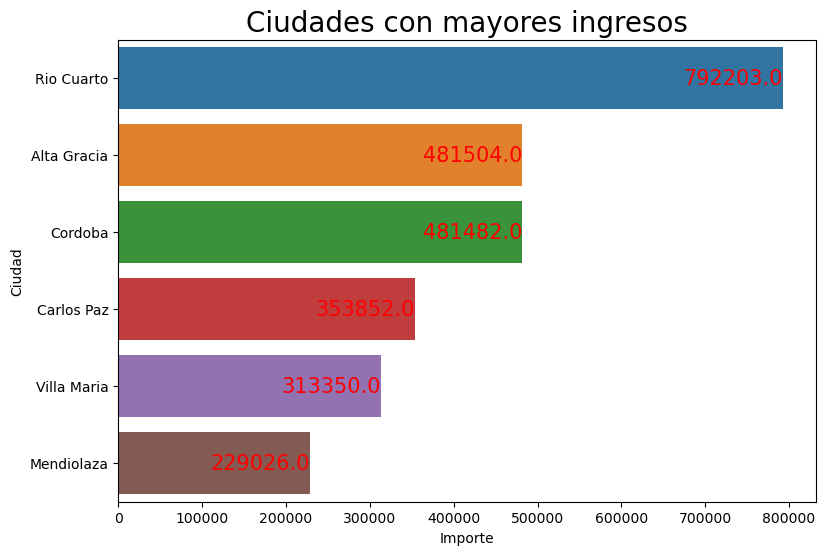

In [33]:
# Visualizaciones
plt.figure(figsize=(9, 6))

sns.barplot(df_ciudad_importe, y='ciudad', x='importe')
plt.xlabel('Importe')
plt.ylabel('Ciudad')
plt.title('Ciudades con mayores ingresos', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_ciudad_importe['importe']):
    plt.text(value - 0.5, i, str(value),
             ha='right', va='center',
             fontsize=15, color='red')

## ¿En qué ciudades se realizaron más compras en cantidad?

In [34]:
query_ciudad_cantidad = '''
                        SELECT cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR) AS ciudad, SUM(dv.cantidad) AS cantidad 
                        FROM dbo.clientes cl
                        INNER JOIN dbo.ciudades cdd ON cdd.id_ciudad = cl.id_ciudad
                        INNER JOIN dbo.ventas vt ON vt.id_cliente = cl.id_cliente
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY cdd.id_ciudad, CAST(cdd.ciudad AS VARCHAR)
                        ORDER BY SUM(dv.cantidad) DESC;
                       '''
df_ciudad_cantidad = pd.read_sql(query_ciudad_cantidad, con)
df_ciudad_cantidad

,id_ciudad,ciudad,cantidad
0,2,Rio Cuarto,299
1,3,Cordoba,200
2,5,Alta Gracia,185
3,1,Carlos Paz,126
4,4,Villa Maria,106
5,6,Mendiolaza,100


In [35]:
porcentaje_participacion_cantidad = np.zeros(6)

for i in range(6):
    porcentaje_participacion_cantidad[i]= round((df_ciudad_cantidad['cantidad'][i]/df_ciudad_cantidad['cantidad'].sum())*100,1)

print(porcentaje_participacion_cantidad)    

[29.4 19.7 18.2 12.4 10.4  9.8]


In [36]:
df_ciudad_cantidad['porcentaje_participacion (%)'] = porcentaje_participacion_cantidad
df_ciudad_cantidad

,id_ciudad,ciudad,cantidad,porcentaje_participacion (%)
0,2,Rio Cuarto,299,29.4
1,3,Cordoba,200,19.7
2,5,Alta Gracia,185,18.2
3,1,Carlos Paz,126,12.4
4,4,Villa Maria,106,10.4
5,6,Mendiolaza,100,9.8


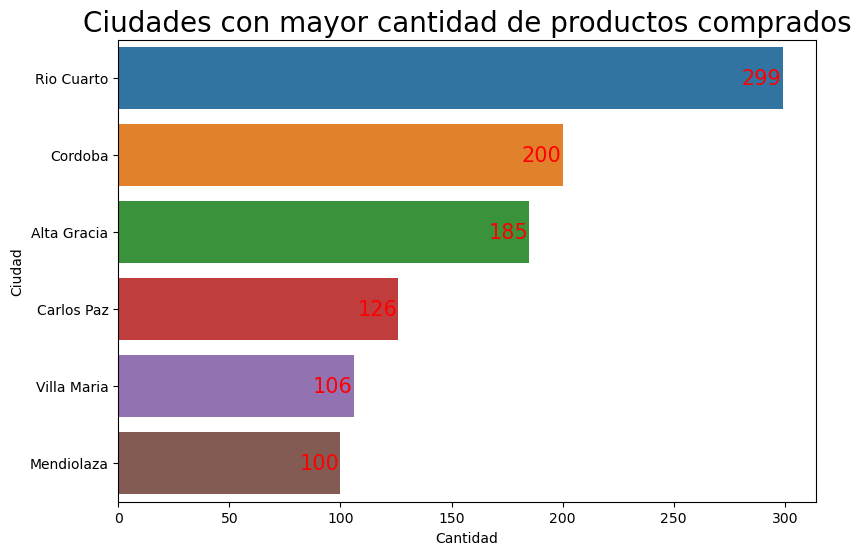

In [37]:
# Visualizaciones
plt.figure(figsize=(9, 6))

sns.barplot(df_ciudad_cantidad, y='ciudad', x='cantidad')
plt.xlabel('Cantidad')
plt.ylabel('Ciudad')
plt.title('Ciudades con mayor cantidad de productos comprados', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_ciudad_cantidad['cantidad']):
    plt.text(value - 0.5, i, str(value),
             ha='right', va='center',
             fontsize=15, color='red')

#### Análisis de Ciudades con mayor cantidad de productos comprados y Ciudades con mayores ingresos


* Río Cuarto, Córdoba y Alta Gracia son las principales ciudades generadoras de ingresos y ventas para la tienda Aurelion.

* Río Cuarto, es la ciudad más importante para la tienda, ya que lidera tanto en ingresos como en cantidad de productos vendidos. Esto sugiere una base de clientes sólida, con alto poder adquisitivo y un volumen de compras considerable.

* Córdoba y Alta Gracia, son mercados estables con potencial de crecimiento; conviene impulsar campañas o descuentos dirigidos.

## ¿Quiénes son los 20 clientes que más compran en términos de ingresos?

In [38]:
query_cliente_importe = '''
                        SELECT cl.id_cliente, CAST(cl.nombre_cliente AS VARCHAR) AS cliente, SUM(dv.cantidad * dv.precio_unitario) AS importe	
                        FROM dbo.clientes cl
                        INNER JOIN dbo.ciudades cdd ON cdd.id_ciudad = cl.id_ciudad
                        INNER JOIN dbo.ventas vt ON vt.id_cliente = cl.id_cliente
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY cl.id_cliente, CAST(cl.nombre_cliente AS VARCHAR)
                        ORDER BY SUM(dv.cantidad * dv.precio_unitario) DESC;
                        '''
df_cliente_importe = pd.read_sql(query_cliente_importe, con)
df_cliente_importe

,id_cliente,cliente,importe
0,5,Agustina Flores,132158.0
1,56,Bruno Diaz,90701.0
2,52,Diego Diaz,90522.0
3,25,Karina Castro,81830.0
4,1,Mariana Lopez,72448.0
...,...,...,...
62,98,Camila Castro,10864.0
63,51,Agustina Gomez,9800.0
64,17,Pablo Gomez,7752.0
65,82,Lucas Lopez,7710.0


Calculamos el porcentaje de participación.

In [39]:
porcentaje_participacion_clientes = np.zeros(len(df_cliente_importe))

for i in range(len(df_cliente_importe)):
    porcentaje_participacion_clientes[i]= round((df_cliente_importe['importe'][i]/df_cliente_importe['importe'].sum())*100,1)

#print(porcentaje_participacion_clientes)    

In [40]:
df_cliente_importe['porcentaje_participacion (%)'] = porcentaje_participacion_clientes
# df_cliente_importe

In [41]:
df_cliente_importe.head(20)

,id_cliente,cliente,importe,porcentaje_participacion (%)
0,5,Agustina Flores,132158.0,5.0
1,56,Bruno Diaz,90701.0,3.4
2,52,Diego Diaz,90522.0,3.4
3,25,Karina Castro,81830.0,3.1
4,1,Mariana Lopez,72448.0,2.7
5,49,Olivia Gomez,71321.0,2.7
6,61,Guadalupe Martinez,67959.0,2.6
7,84,Pablo Sanchez,67575.0,2.5
8,72,Camila Rodriguez,65001.0,2.5
9,39,Santiago Diaz,64786.0,2.4


#### Análisis:

* Agustina Flores destaca como la clienta que más ingresos generó para la tienda, posicionándose como la principal contribuyente en términos de ventas totales.

* Bruno Diaz, Diego Diaz y Karina Castro ocupan las siguientes posiciones, con montos que oscilan entre 81830.0 y 90,000, lo que evidencia un segmento de clientes con alto nivel de gasto y potencial valor para la empresa.

## ¿Cuál es la compra media por cliente mensualmente?

In [93]:
query_mes_clientes = '''
                        SELECT MONTH(vt.fecha) AS mes, 
                              FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes,
                              COUNT(DISTINCT(vt.id_cliente)) AS cantidad_clientes 
                        FROM dbo.ventas AS vt
                        GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                        ORDER BY MONTH(vt.fecha) ASC;
                     '''
df_mes_clientes = pd.read_sql(query_mes_clientes, con)
df_mes_clientes

,mes,nombre_mes,cantidad_clientes
0,1,enero,23
1,2,febrero,17
2,3,marzo,19
3,4,abril,11
4,5,mayo,17
5,6,junio,18


In [100]:
df_tendencia_ingresos
compra_media_por_cliente = {}

for i in range(df_mes_clientes.shape[0]):
    mes = df_mes_clientes.iloc[i, 1]  # Suponiendo que la primera columna es 'mes'
    importe = df_tendencia_ingresos.iloc[i, 2]
    clientes = df_mes_clientes.iloc[i, 2]

    compra_media_por_cliente[mes] = round(importe / clientes, 2)
print(compra_media_por_cliente)

{'enero': 23036.52, 'febrero': 23943.59, 'marzo': 20434.89, 'abril': 22865.82, 'mayo': 33048.94, 'junio': 28495.39}


In [101]:
compra_media_por_cliente = pd.DataFrame(compra_media_por_cliente.items(), columns=['mes', 'compra_media_por_cliente'])
compra_media_por_cliente

,mes,compra_media_por_cliente
0,enero,23036.52
1,febrero,23943.59
2,marzo,20434.89
3,abril,22865.82
4,mayo,33048.94
5,junio,28495.39


d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


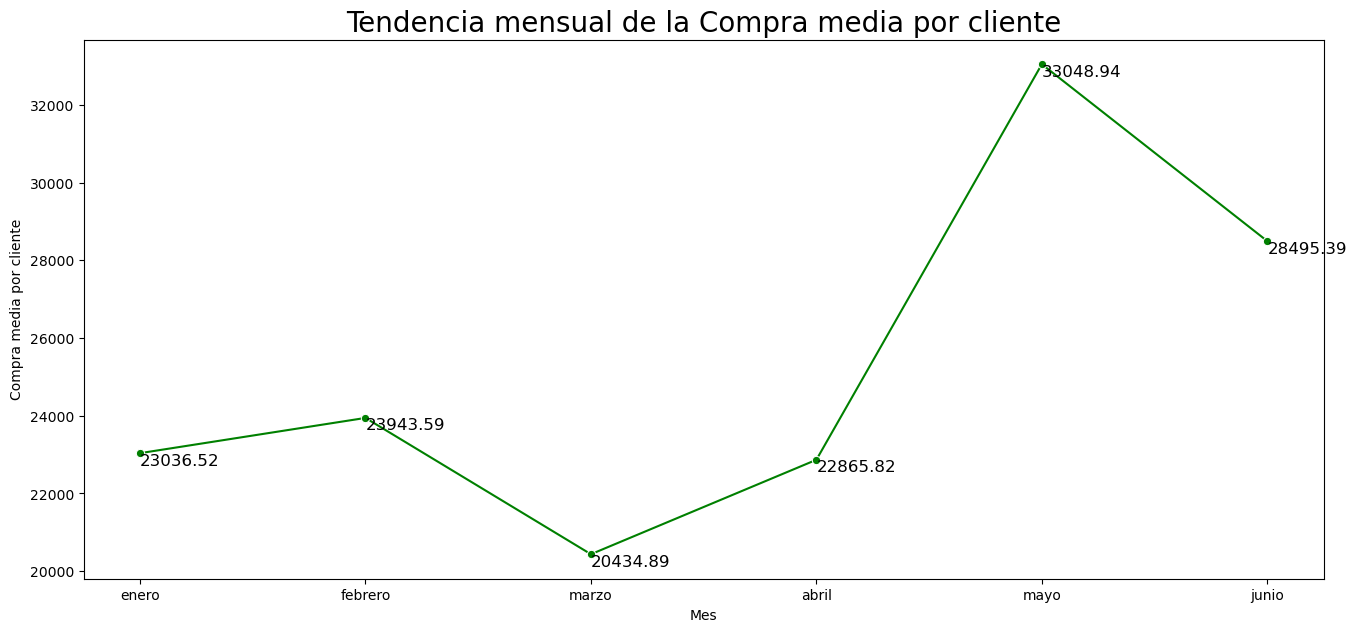

In [103]:
plt.figure(figsize=(16, 7))

# Crear el gráfico de líneas
sns.lineplot(compra_media_por_cliente, x= 'mes', y = 'compra_media_por_cliente', color = 'green', linestyle='-', marker='o')

# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('Compra media por cliente')
plt.title("Tendencia mensual de la Compra media por cliente", fontsize = 20)
# Agregar etiquetas sobre cada punto
for i in range(len(compra_media_por_cliente)):
    plt.text(compra_media_por_cliente['mes'][i],
             compra_media_por_cliente['compra_media_por_cliente'][i] + 5,   # Ajusta la altura de la etiqueta
             str(compra_media_por_cliente['compra_media_por_cliente'][i]),
             ha='left', va='top', fontsize=12, color='black')

    # Valor promedio por pedido
    # interpretación: refleja el monto promedio gastado cada vez que se realiza una compra.

#### Análisis:

* El mes de marzo (20434.89 ARS) registró el menor gasto promedio por cliente, lo que coincide con una reducción progresiva en las ventas y pedido. Esto indica un periodo de baja actividad comercial.

* En mayo, el gasto promedio por cliente alcanzó su máximo valor (30359.82 ARS). Aunque no fue el mes con mayor cantidad vendida, este resultado sugiere que los clientes realizaron compras de mayor valor unitario, elevando así el ingreso total.

* En junio, el gasto promedio por cliente fue de 26133.17 ARS, manteniéndose en un nivel alto respecto a los meses anteriores, aunque con una ligera disminución respecto a mayo.

## ¿Cuántos pedidos totales se han realizado?

In [42]:
query_pedidos_totales = '''
                        SELECT COUNT(*) AS Total_pedidos  FROM dbo.ventas;
                        '''
df_pedidos_totales = pd.read_sql(query_pedidos_totales, con)
df_pedidos_totales

,Total_pedidos
0,120


## ¿Cuál es el valor promedio por pedido mensualmente?

In [72]:
query_ventas_por_mes = '''
                        SELECT MONTH(vt.fecha) AS mes, FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes, COUNT(*) AS cantidad_de_ventas 
                        FROM dbo.ventas AS vt
                        GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                        ORDER BY MONTH(vt.fecha) ASC;
                       '''
df_ventas_por_mes = pd.read_sql(query_ventas_por_mes, con)
df_ventas_por_mes

,mes,nombre_mes,cantidad_de_ventas
0,1,enero,24
1,2,febrero,20
2,3,marzo,21
3,4,abril,12
4,5,mayo,22
5,6,junio,21


In [73]:
query_importe_por_mes = '''
                        SELECT MONTH(vt.fecha) AS mes, 
                                FORMAT(vt.fecha, 'MMMM', 'es-ES') AS nombre_mes, 
                                SUM(dv.cantidad * dv.precio_unitario) AS importe 
                        FROM dbo.ventas AS vt
                        INNER JOIN dbo.detalle_ventas dv ON dv.id_venta = vt.id_venta
                        GROUP BY MONTH(vt.fecha), FORMAT(vt.fecha, 'MMMM', 'es-ES')
                        ORDER BY MONTH(vt.fecha) ASC;
                       '''
df_importe_por_mes = pd.read_sql(query_importe_por_mes, con)
df_importe_por_mes

,mes,nombre_mes,importe
0,1,enero,529840.0
1,2,febrero,407041.0
2,3,marzo,388263.0
3,4,abril,251524.0
4,5,mayo,561832.0
5,6,junio,512917.0


In [78]:
valor_promedio_por_pedido = {}

for i in range(len(df_ventas_por_mes)):
    mes = df_ventas_por_mes.iloc[i, 1]  
    importe = df_importe_por_mes.iloc[i, 2]
    ventas = df_ventas_por_mes.iloc[i, 2]

    valor_promedio_por_pedido[mes] = round(importe / ventas, 2)
print(valor_promedio_por_pedido)

{'enero': 22076.67, 'febrero': 20352.05, 'marzo': 18488.71, 'abril': 20960.33, 'mayo': 25537.82, 'junio': 24424.62}


In [79]:
valor_promedio_por_pedido = pd.DataFrame(valor_promedio_por_pedido.items(), columns=['mes', 'valor_promedio_por_pedido'])
valor_promedio_por_pedido

,mes,valor_promedio_por_pedido
0,enero,22076.67
1,febrero,20352.05
2,marzo,18488.71
3,abril,20960.33
4,mayo,25537.82
5,junio,24424.62


d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
d:\Anacondapython\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


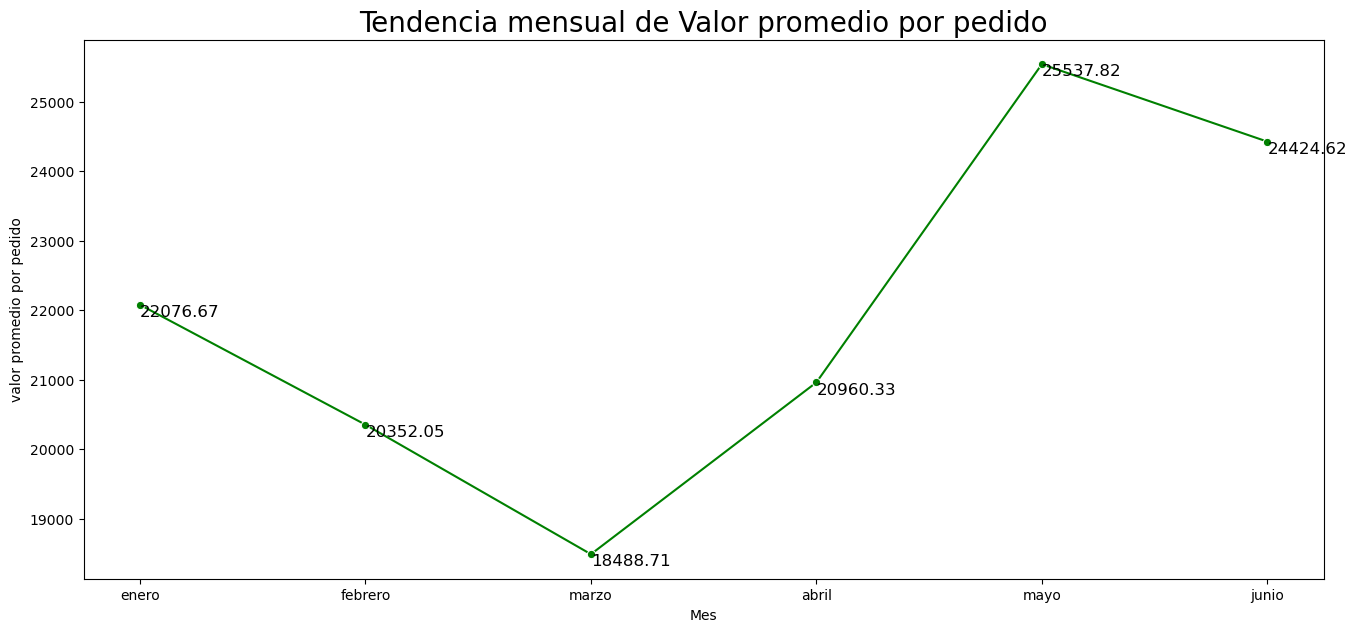

In [83]:
plt.figure(figsize=(16, 7))

# Crear el gráfico de líneas
sns.lineplot(valor_promedio_por_pedido, x= 'mes', y = 'valor_promedio_por_pedido', color = 'green', linestyle='-', marker='o')

# Etiquetas de los ejes
plt.xlabel('Mes')
plt.ylabel('valor promedio por pedido')
plt.title("Tendencia mensual de Valor promedio por pedido", fontsize = 20)
# Agregar etiquetas sobre cada punto
for i in range(len(valor_promedio_por_pedido)):
    plt.text(valor_promedio_por_pedido['mes'][i],
             valor_promedio_por_pedido['valor_promedio_por_pedido'][i] + 5,   # Ajusta la altura de la etiqueta
             str(valor_promedio_por_pedido['valor_promedio_por_pedido'][i]),
             ha='left', va='top', fontsize=12, color='black')
plt.show()

#### Análisis:

* El mes 3 (17,514.9) registró el menor Valor Promedio por Pedido. Este valor mínimo se produce en medio de una reducción progresiva en los ingresos y cantidad vendidad, lo que indica que los clientes compraron ítems de precio unitario bajo.

* En el mes 5, se alcanzó su máximo monto promedio gastado por cada pedido , combinado con la recuperación del ingreso y cantiadad vendidad.Lo que índica que los clientes compraron ítems de precio unitario más levado.

## ¿Cuáles son las categorías más vendidas en cantidad?

In [43]:
query_categoria_cantidad = '''
                            SELECT ct.id_categoria, ct.categoria, SUM(dv.cantidad) AS cantidad FROM dbo.detalle_ventas dv
                            INNER JOIN dbo.productos prod ON prod.id_producto = dv.id_producto
                            INNER JOIN dbo.categorias ct ON ct.id_categoria = prod.id_categoria
                            GROUP BY ct.id_categoria, ct.categoria;
                           '''
df_categoria_cantidad = pd.read_sql(query_categoria_cantidad, con)
df_categoria_cantidad

,id_categoria,categoria,cantidad
0,1,Alimentos,498
1,2,Limpieza,518


In [44]:
porcentaje_participacion_categorias = np.zeros(len(df_categoria_cantidad))

for i in range(len(df_categoria_cantidad)):
    porcentaje_participacion_categorias[i]= round((df_categoria_cantidad['cantidad'][i]/df_categoria_cantidad['cantidad'].sum())*100,1)

print(porcentaje_participacion_categorias)    

[49. 51.]


In [45]:
df_categoria_cantidad['porcentaje_participacion (%)'] = porcentaje_participacion_categorias

In [46]:
df_categoria_cantidad

,id_categoria,categoria,cantidad,porcentaje_participacion (%)
0,1,Alimentos,498,49.0
1,2,Limpieza,518,51.0


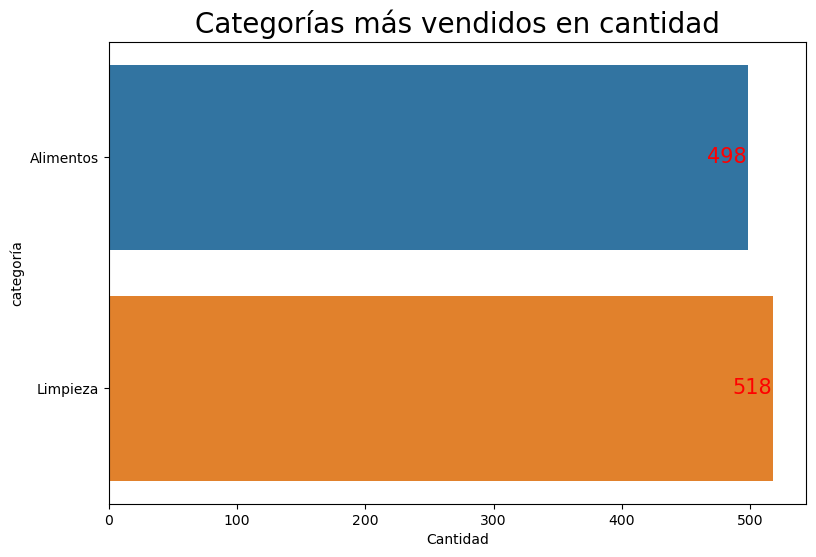

In [47]:
# Visualizaciones
plt.figure(figsize=(9, 6))

sns.barplot(df_categoria_cantidad, y='categoria', x='cantidad')
plt.xlabel('Cantidad')
plt.ylabel('categoría')
plt.title('Categorías más vendidos en cantidad', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_categoria_cantidad['cantidad']):
    plt.text(value - 0.5, i, str(value),
             ha='right', va='center',
             fontsize=15, color='red')

## ¿Qué categorías generan más ingresos?

In [48]:
query_categoria_importe = '''
                            SELECT ct.id_categoria, ct.categoria, SUM(dv.cantidad * dv.precio_unitario) AS importe FROM dbo.detalle_ventas dv
                            INNER JOIN dbo.productos prod ON prod.id_producto = dv.id_producto
                            INNER JOIN dbo.categorias ct ON ct.id_categoria = prod.id_categoria
                            GROUP BY ct.id_categoria, ct.categoria;
                           '''
df_categoria_importe = pd.read_sql(query_categoria_importe, con)
df_categoria_importe

,id_categoria,categoria,importe
0,1,Alimentos,1215136.0
1,2,Limpieza,1436281.0


In [49]:
porcentaje_participacion_categorias = np.zeros(len(df_categoria_importe))

for i in range(len(df_categoria_importe)):
    porcentaje_participacion_categorias[i]= round((df_categoria_importe['importe'][i]/df_categoria_importe['importe'].sum())*100,1)

print(porcentaje_participacion_categorias) 

[45.8 54.2]


In [50]:
df_categoria_importe['porcentaje_participacion (%)'] = porcentaje_participacion_categorias

In [51]:
df_categoria_importe

,id_categoria,categoria,importe,porcentaje_participacion (%)
0,1,Alimentos,1215136.0,45.8
1,2,Limpieza,1436281.0,54.2


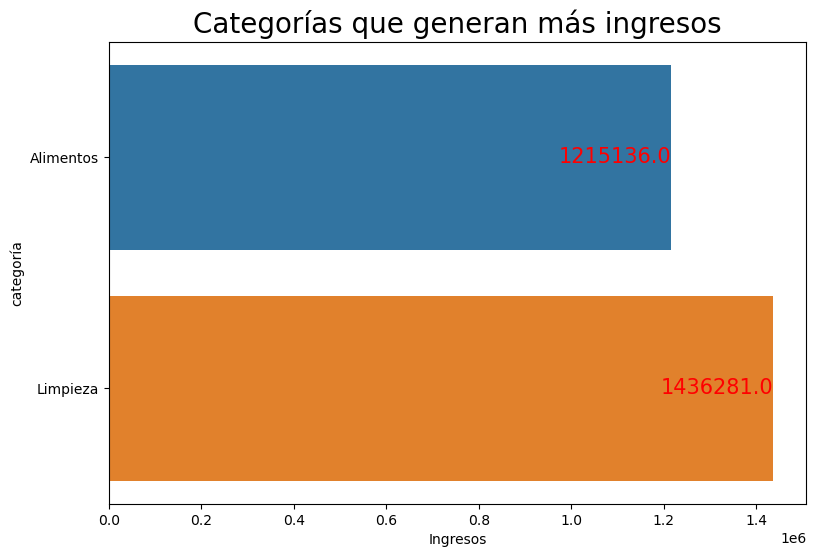

In [52]:
# Visualizaciones
plt.figure(figsize=(9, 6))

sns.barplot(df_categoria_importe, y='categoria', x='importe')
plt.xlabel('Ingresos')
plt.ylabel('categoría')
plt.title('Categorías que generan más ingresos', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_categoria_importe['importe']):
    plt.text(value - 0.5, i, str(value),
             ha='right', va='center',
             fontsize=15, color='red')

### Análisis de las dos visualizaciones
- Limpieza  es la categoría con mayor volumen de ventas, alcanzando 518 unidades vendidas. Esto indica que es la categoría con mayor rotación y frecuencia de compra.

- La categoría Limpieza genera más ingresos totales. Esto ocurre porque los productos de limpieza tienen un precio promedio más alto y más cantidad vendida.

## ¿Cuáles son los 10 productos más vendidos en cantidad?

In [53]:
query_producto_cantidad = '''
                            SELECT prod.id_producto, CAST(prod.nombre_producto AS VARCHAR) AS nombre_producto, SUM(dv.cantidad) AS cantidad  
                            FROM dbo.detalle_ventas dv
                            INNER JOIN dbo.productos prod ON prod.id_producto = dv.id_producto
                            GROUP BY prod.id_producto, CAST(prod.nombre_producto AS VARCHAR)
                            ORDER BY SUM(dv.cantidad) DESC;
                           '''
df_producto_cantidad = pd.read_sql(query_producto_cantidad, con)
df_producto_cantidad

,id_producto,nombre_producto,cantidad
0,43,Salsa de Tomate 500g,27
1,18,Queso Rallado 150g,26
2,79,Hamburguesas Congeladas x4,24
3,81,Aceitunas Verdes 200g,22
4,68,Vino Blanco 750ml,22
...,...,...,...
90,16,Yogur Natural 200g,3
91,33,Chocolate con Leche 100g,2
92,25,Galletitas Vainilla,2
93,26,Alfajor Triple,2


Porcentaje de participación

In [54]:
porcentaje_participacion_productos = np.zeros(len(df_producto_cantidad))

for i in range(len(df_producto_cantidad)):
    porcentaje_participacion_productos[i]= round((df_producto_cantidad['cantidad'][i]/df_producto_cantidad['cantidad'].sum())*100,1)

# print(porcentaje_participacion_productos) 

In [55]:
df_producto_cantidad['porcentaje_participacion (%)'] = porcentaje_participacion_productos
df_producto_cantidad

,id_producto,nombre_producto,cantidad,porcentaje_participacion (%)
0,43,Salsa de Tomate 500g,27,2.7
1,18,Queso Rallado 150g,26,2.6
2,79,Hamburguesas Congeladas x4,24,2.4
3,81,Aceitunas Verdes 200g,22,2.2
4,68,Vino Blanco 750ml,22,2.2
...,...,...,...,...
90,16,Yogur Natural 200g,3,0.3
91,33,Chocolate con Leche 100g,2,0.2
92,25,Galletitas Vainilla,2,0.2
93,26,Alfajor Triple,2,0.2


In [56]:
df_producto_cantidad_10 = df_producto_cantidad.head(10)
df_producto_cantidad_10

,id_producto,nombre_producto,cantidad,porcentaje_participacion (%)
0,43,Salsa de Tomate 500g,27,2.7
1,18,Queso Rallado 150g,26,2.6
2,79,Hamburguesas Congeladas x4,24,2.4
3,81,Aceitunas Verdes 200g,22,2.2
4,68,Vino Blanco 750ml,22,2.2
5,72,Ron 700ml,21,2.1
6,38,Mermelada de Frutilla 400g,21,2.1
7,53,Lavandina 1L,21,2.1
8,76,Pizza Congelada Muzzarella,20,2.0
9,9,Yerba Mate Suave 1kg,20,2.0


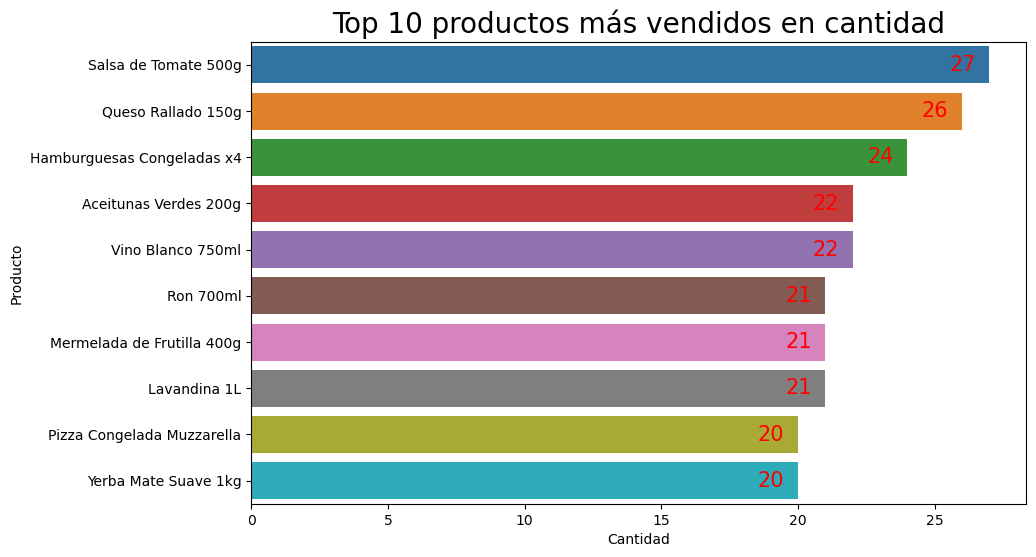

In [57]:
# Visualizaciones
plt.figure(figsize=(10, 6))

sns.barplot(df_producto_cantidad_10, y='nombre_producto', x='cantidad')
plt.xlabel('Cantidad')
plt.ylabel('Producto')
plt.title('Top 10 productos más vendidos en cantidad', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_producto_cantidad_10['cantidad']):
    plt.text(value - 0.5, i, str(value), ha='right', va='center',
             fontsize=15, color='red')

## ¿Cuáles son los 10 productos que generan más ingresos?

In [58]:
query_producto_importe = '''
                            SELECT prod.id_producto, CAST(prod.nombre_producto AS VARCHAR) AS nombre_producto, SUM(dv.cantidad * dv.precio_unitario) AS importe  
                            FROM dbo.detalle_ventas dv
                            INNER JOIN dbo.productos prod ON prod.id_producto = dv.id_producto
                            GROUP BY prod.id_producto, CAST(prod.nombre_producto AS VARCHAR)
                            ORDER BY SUM(dv.cantidad * dv.precio_unitario) DESC;
                           '''
df_producto_importe = pd.read_sql(query_producto_importe, con)
df_producto_importe.head()

,id_producto,nombre_producto,importe
0,91,Desodorante Aerosol,93800.0
1,18,Queso Rallado 150g,89544.0
2,76,Pizza Congelada Muzzarella,85720.0
3,72,Ron 700ml,81396.0
4,9,Yerba Mate Suave 1kg,77560.0


In [59]:
porcentaje_participacion_productos = np.zeros(len(df_producto_importe))

for i in range(len(df_producto_importe)):
    porcentaje_participacion_productos[i]= round((df_producto_importe['importe'][i]/df_producto_importe['importe'].sum())*100,1)

# print(porcentaje_participacion_productos) 

In [60]:
df_producto_importe['porcentaje_participacion (%)'] = porcentaje_participacion_productos
df_producto_importe

,id_producto,nombre_producto,importe,porcentaje_participacion (%)
0,91,Desodorante Aerosol,93800.0,3.5
1,18,Queso Rallado 150g,89544.0,3.4
2,76,Pizza Congelada Muzzarella,85720.0,3.2
3,72,Ron 700ml,81396.0,3.1
4,9,Yerba Mate Suave 1kg,77560.0,2.9
...,...,...,...,...
90,12,Té Negro 20 saquitos,3990.0,0.2
91,21,Pan Lactal Integral,2992.0,0.1
92,33,Chocolate con Leche 100g,2510.0,0.1
93,71,Vodka 700ml,2032.0,0.1


In [61]:
df_producto_importe_10 = df_producto_importe.head(10)
df_producto_importe_10

,id_producto,nombre_producto,importe,porcentaje_participacion (%)
0,91,Desodorante Aerosol,93800.0,3.5
1,18,Queso Rallado 150g,89544.0,3.4
2,76,Pizza Congelada Muzzarella,85720.0,3.2
3,72,Ron 700ml,81396.0,3.1
4,9,Yerba Mate Suave 1kg,77560.0,2.9
5,8,Energética Nitro 500ml,71706.0,2.7
6,59,Chicle Menta,68628.0,2.6
7,58,Caramelos Masticables,66528.0,2.5
8,68,Vino Blanco 750ml,59048.0,2.2
9,79,Hamburguesas Congeladas x4,58080.0,2.2


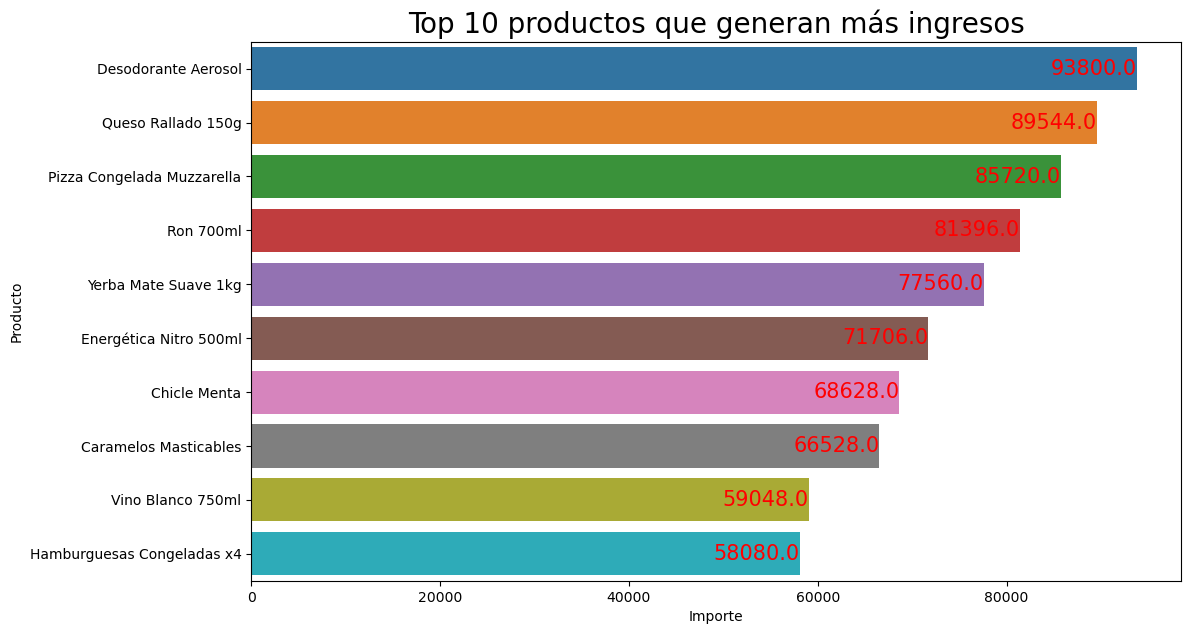

In [62]:
# Visualizaciones
plt.figure(figsize=(12, 7))

sns.barplot(df_producto_importe_10, y='nombre_producto', x='importe')
plt.xlabel('Importe')
plt.ylabel('Producto')
plt.title('Top 10 productos que generan más ingresos', fontsize = 20)

# Añadir etiquetas con los valores
for i, value in enumerate(df_producto_importe_10['importe']):
    plt.text(value - 2.5, i, str(value), ha='right', va='center',
             fontsize=15, color='red')

#### Teniendo en cuenta los 10 productos más vendidos en cantidad y los 10 productos que generan más ingresos.

#### Análisis:

* Queso Rallado 150g ocupa el segundo lugar tanto en cantidad vendida como en ingresos. Es un producto importante para la tienda porque se vende bien y deja buenas ganancias.

* Salsa de Tomate 500g es el producto que más se vende, pero genera pocas ganancias porque su precio es bajo. Aun así, es un producto que los clientes compran con frecuencia y ayuda a mantener buenas ventas.

* Desodorante Aerosol es el producto que más dinero genera, aunque se vende en menor cantidad. Su precio es alto, por eso aporta buenas ganancias, pero no todos los clientes lo compran.

* Chicle Menta, Pizza Congelada Muzzarella y Trapo de Piso no estan entre los 10 productos más vendidos en cantidad, pero igual aportan bastante dinero a la tienda porque tienen precios más altos. Esto puede hacer que la gente los compre con menos frecuencia.